In [33]:
import Interactions
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

In [34]:
const = Interactions.PhysicalConstants()

In [35]:
AzoTAB_cis = Interactions.Surfactant(
    cmc = 0.82,
    charge_fraction = 0.2, #20% of the aggregation number means that i think
    aggregation_number = 182,
    mycel_diameter = 6.03E-9,
    delta = 0.75 #we'll have to sort this out
)

AzoTAB_trans = Interactions.Surfactant(
    cmc = 0.34,
    charge_fraction = 0.2, 
    aggregation_number = 513,
    mycel_diameter= 8.86E-9, 
    delta = 0 #kept the same as CTAC
    
)

CTAC = Interactions.Surfactant(
    cmc = 1.31,
    charge_fraction = 0.28, 
    aggregation_number = 120,
    mycel_diameter= 4.6E-9, 
    delta = 0
)


In [36]:
sol_cis = Interactions.SolutionState(
    temperature= 298.0,
    eps_r = 80, # I imagine we're in water
    surfactants=(AzoTAB_cis,AzoTAB_trans),
    layer_thickness = 1.5E-9, #this is related to the screening surfactant
    zeta_pot = 40E-3,
    composition = 0
)

sol_trans = Interactions.SolutionState(
    temperature= 298.0,
    eps_r = 80, # I imagine we're in water
    surfactants=(AzoTAB_trans,AzoTAB_cis),
    layer_thickness = 1.5E-9, #this is related to the screening surfactant
    zeta_pot = 40E-3,
    composition = 0
)

In [40]:
#testing the objects first then how to handle length and bla bla


rod = Interactions.RodSpecies(
    width = 30E-9,
    length = 260E-9,
    hamaker = 9E-20 
)




33.053053053053056
93.1131131131131


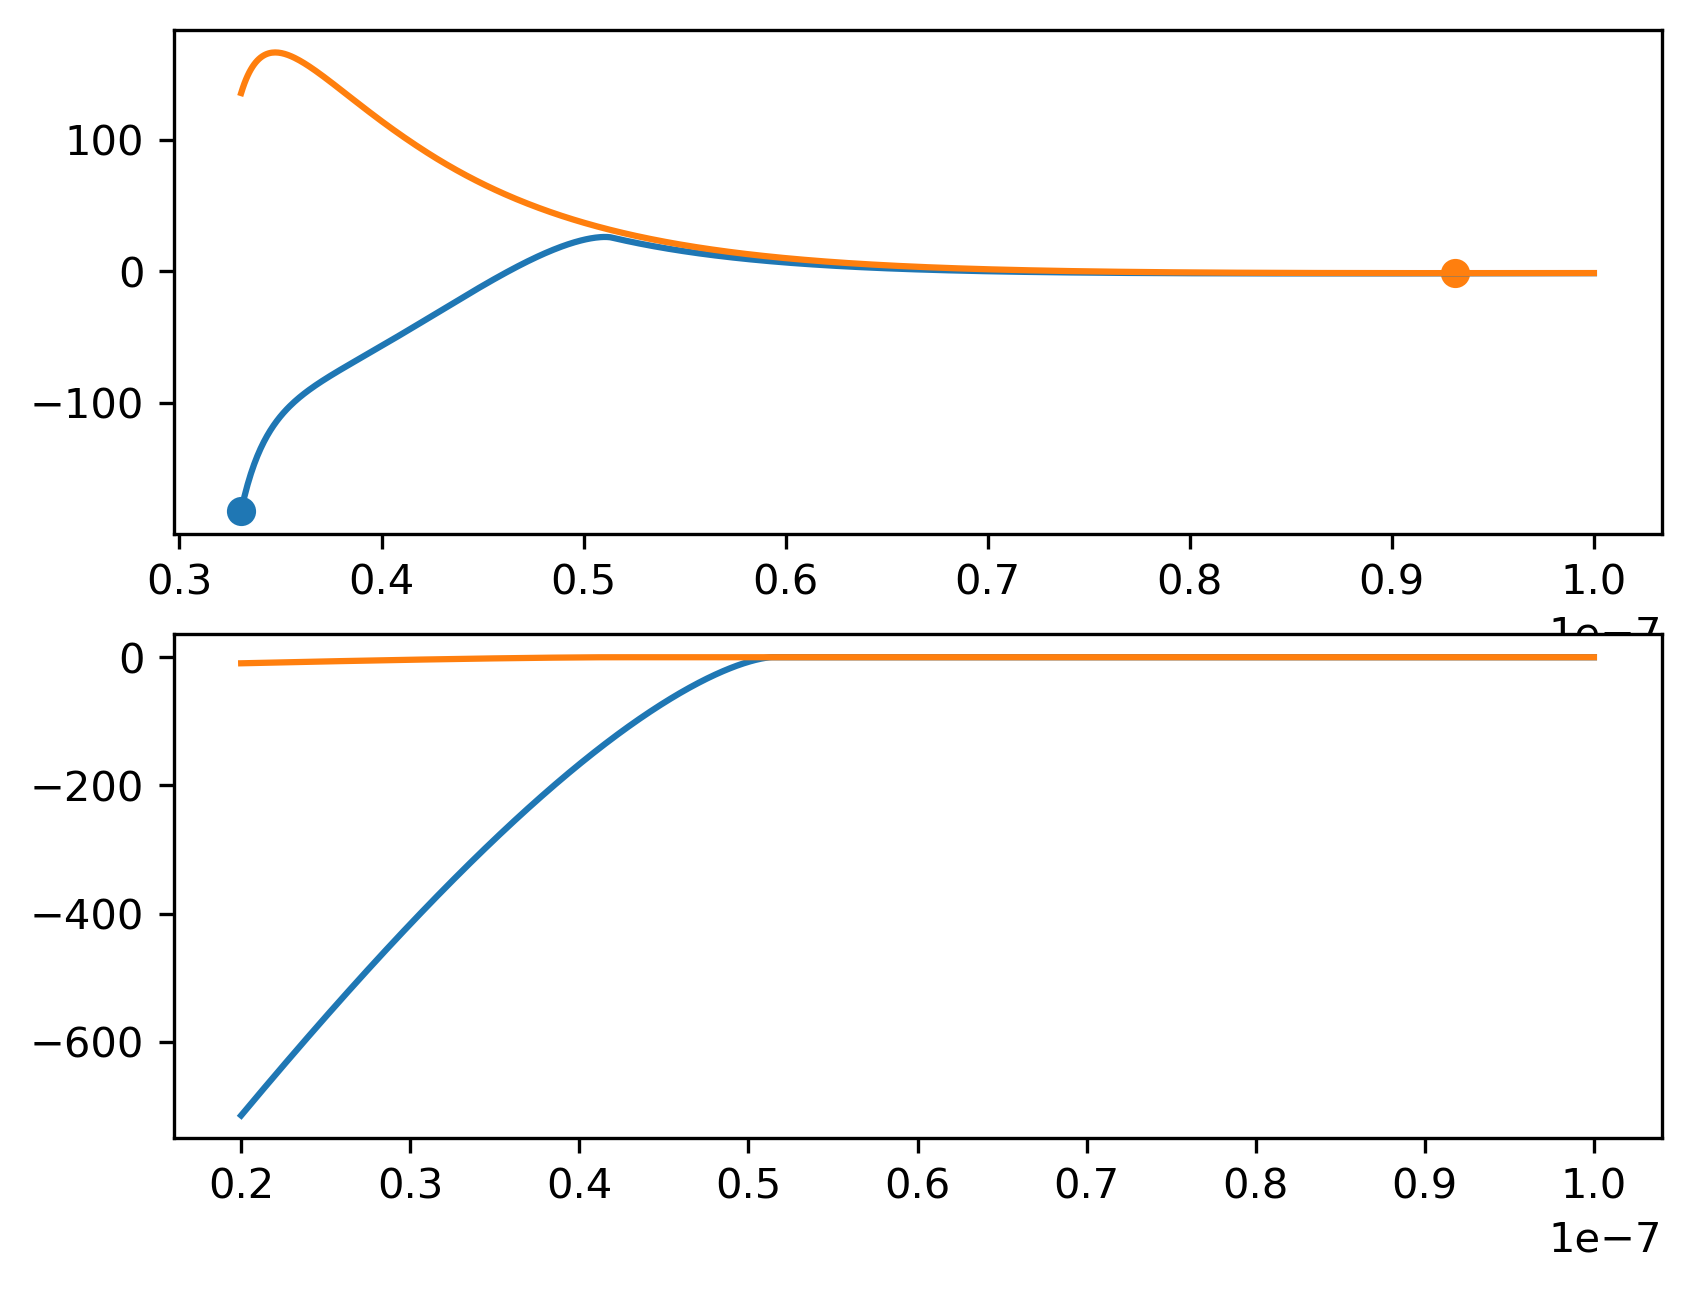

In [43]:
conc = 50
spacing = np.linspace(20E-9, 100E-9, 1000)
vdw = Interactions.VdWInteraction()
el = Interactions.ElectrostaticInteraction()
ao = Interactions.DepletionInteraction()

fig, ax = plt.subplots(2, 1)

en_vdw = vdw.energy(rod, rod, spacing)/(const.k_B*sol_cis.temperature)*rod.length
en_el = el.energy(rod, rod, spacing, sol_cis, conc)/(const.k_B*sol_cis.temperature)*rod.length
en_ao = ao.energy(rod, rod, spacing, sol_cis, conc)/(const.k_B*sol_cis.temperature)*rod.length
en_tot =  en_el + en_vdw + en_ao
ax[0].plot(spacing, en_tot)
ax[1].plot(spacing, en_ao)
min = [spacing[np.argmin(en_tot)], np.min(en_tot)]
ax[0].scatter(min[0], min[1])
print(min[0]*1e9)

en_vdw = vdw.energy(rod, rod, spacing)/(const.k_B*sol_trans.temperature)*rod.length
en_el = el.energy(rod, rod, spacing, sol_trans, conc)/(const.k_B*sol_trans.temperature)*rod.length
en_ao = ao.energy(rod, rod, spacing, sol_trans, conc)/(const.k_B*sol_trans.temperature)*rod.length
en_tot =  en_el + en_vdw + en_ao
ax[0].plot(spacing, en_tot)
ax[1].plot(spacing, en_ao)
min = [spacing[np.argmin(en_tot)], np.min(en_tot)]
print(min[0]*1e9)
ax[0].scatter(min[0], min[1])


##print(sol_cis.inverse_debye(conc))
##print(sol_trans.inverse_debye(conc))




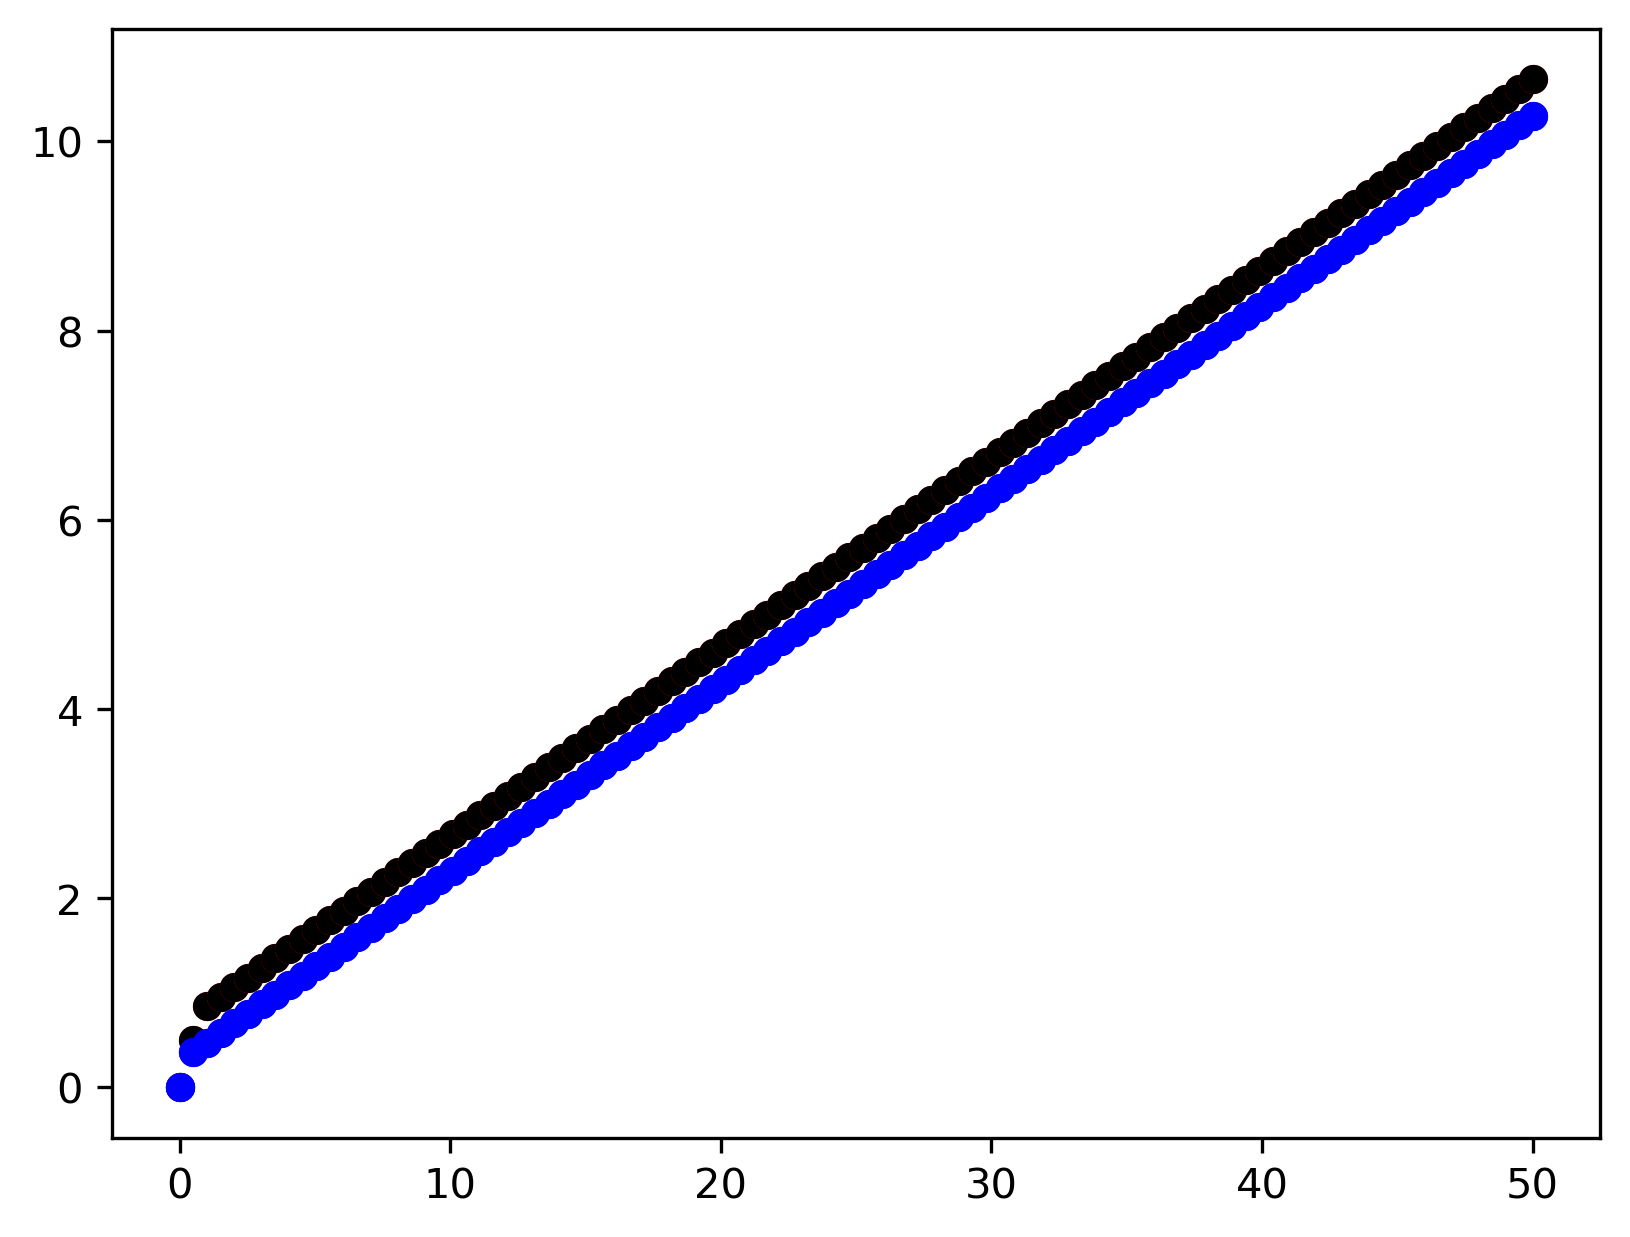

In [ ]:
#small micelles have a deeper minimum